# Team 02 — Feature Engineering
## DATA 4950 Data Science Capstone — Notebook 03
**Dataset:** Online Shoppers Purchasing Intention  
**Target:** `Revenue` (binary classification — did the session end in a purchase?)


## Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')


---
## Section 1 — Load Preprocessed Data (10 pts)

Notebook 02 loaded the raw CSV, confirmed there were no missing values or duplicates, 
converted `Revenue` from bool to int, and performed an 80/20 stratified train-test split 
with `random_state=4950`. We reproduce that identical split here from the raw CSV so that 
all four arrays (`X_train`, `X_test`, `y_train`, `y_test`) exactly match the Notebook 02 outputs.


In [3]:
# Reproduce the Notebook 02 pipeline (no leakage — split is identical)
df = pd.read_csv("../data/raw/online_shoppers_intention.csv")
df = df.drop_duplicates()
df['Revenue'] = df['Revenue'].astype(int)

X = df.drop('Revenue', axis=1)
y = df['Revenue']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=4950, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test  shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test  shape:", y_test.shape)


X_train shape: (9764, 17)
X_test  shape: (2441, 17)
y_train shape: (9764,)
y_test  shape: (2441,)


In [4]:
# Identify column types in X_train
numeric_cols = X_train.select_dtypes(include='number').columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object', 'bool']).columns.tolist()
print(f"Numeric features  ({len(numeric_cols)}): {numeric_cols}")
print()
print(f"Categorical/bool features ({len(categorical_cols)}): {categorical_cols}")


Numeric features  (14): ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']

Categorical/bool features (3): ['Month', 'VisitorType', 'Weekend']


### Confirmation

| Item | Value |
|---|---|
| X_train shape | (9764, 17) |
| X_test shape  | (2441, 17) |
| Numeric features | 14 (`Administrative`, `Administrative_Duration`, `Informational`, `Informational_Duration`, `ProductRelated`, `ProductRelated_Duration`, `BounceRates`, `ExitRates`, `PageValues`, `SpecialDay`, `OperatingSystems`, `Browser`, `Region`, `TrafficType`) |
| Categorical features | 2 (`Month`, `VisitorType`) |
| Boolean features | 1 (`Weekend`) |

### Engineering Plan

| Column(s) | Planned Technique |
|---|---|
| `ProductRelated`, `ProductRelated_Duration` | **Ratio** — pages browsed per second of duration |
| `PageValues` | **Log transform** — strong right-skew |
| `BounceRates`, `ExitRates` | **Interaction** — combined disengagement signal |
| `PageValues` | **Binary flag** — did session access a high-value page? |
| `Administrative` + `Informational` + `ProductRelated` | **Binning** — total pages into engagement tiers |
| `Month` | **Domain feature** — flag for holiday shopping season (Nov/Dec) |


---
## Section 2 — Create New Features (25 pts)

Six new features are engineered below, spanning **ratio**, **log transformation**,
**interaction**, **binary flag**, **binning**, and **domain-specific** techniques.
Every feature is applied identically to both `X_train` and `X_test`.  
No fitting is required for arithmetic features; bin edges derived from train data
are reused on test.


In [5]:
# Work on copies to preserve originals
X_train = X_train.copy()
X_test  = X_test.copy()


### Feature 1 — `PR_PagePerSec` (Ratio)

**What:** Number of product-related pages divided by the duration spent on them (seconds + 1
to avoid division by zero). This gives a *browsing speed* — how quickly a user pages through products.

**Why it may help:** A fast pacer who clicks through many pages quickly may behave differently
from a slow, deliberate reader. The raw counts alone don't capture this efficiency signal.

A value near 0 means the user spent a lot of time on few pages (deep engagement); a high value
means rapid shallow browsing.


In [6]:
X_train['PR_PagePerSec'] = X_train['ProductRelated'] / (X_train['ProductRelated_Duration'] + 1)
X_test['PR_PagePerSec']  = X_test['ProductRelated']  / (X_test['ProductRelated_Duration']  + 1)

print("PR_PagePerSec — train distribution:")
print(X_train['PR_PagePerSec'].describe().round(4))


PR_PagePerSec — train distribution:
count    9764.0000
mean        0.1144
std         0.3962
min         0.0000
25%         0.0220
50%         0.0340
75%         0.0550
max        11.0000
Name: PR_PagePerSec, dtype: float64


### Feature 2 — `LogPageValues` (Log Transformation)

**What:** `np.log1p()` applied to `PageValues`, which measures the average dollar value of
pages visited. The raw feature has extreme right skew — median is 0, max is ~362.

**Why it may help:** Linear models and distance-based algorithms are sensitive to scale.
Log-transforming compresses the long tail and makes the distribution approximately normal,
giving the model a better opportunity to detect the relationship between page value and revenue.


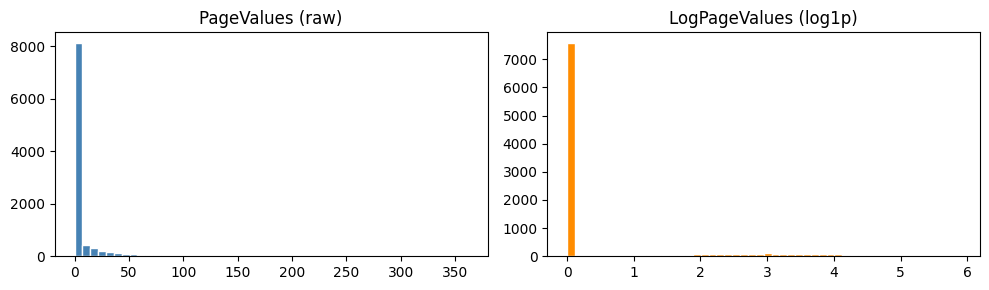

Skewness before: 6.43 | after: 1.78


In [7]:
X_train['LogPageValues'] = np.log1p(X_train['PageValues'])
X_test['LogPageValues']  = np.log1p(X_test['PageValues'])

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(X_train['PageValues'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('PageValues (raw)')
axes[1].hist(X_train['LogPageValues'], bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('LogPageValues (log1p)')
plt.tight_layout()
plt.savefig('log_transform.png', dpi=80, bbox_inches='tight')
plt.show()
print("Skewness before:", round(X_train['PageValues'].skew(), 2),
      "| after:", round(X_train['LogPageValues'].skew(), 2))


### Feature 3 — `Bounce_x_Exit` (Interaction)

**What:** Product of `BounceRates` and `ExitRates` for each session.

**Why it may help:** Both features independently capture disengagement, but their *joint*
level should be a stronger signal. A session with both a high bounce rate *and* a high exit
rate is much more likely to be a non-purchase session than one with only one elevated metric.
The interaction term lets the model capture this non-additive relationship.


In [8]:
X_train['Bounce_x_Exit'] = X_train['BounceRates'] * X_train['ExitRates']
X_test['Bounce_x_Exit']  = X_test['BounceRates']  * X_test['ExitRates']

print("Bounce_x_Exit — train distribution:")
print(X_train['Bounce_x_Exit'].describe().round(6))


Bounce_x_Exit — train distribution:
count    9764.000000
mean        0.002789
std         0.008857
min         0.000000
25%         0.000000
50%         0.000041
75%         0.000556
max         0.040000
Name: Bounce_x_Exit, dtype: float64


### Feature 4 — `HighValueVisit` (Binary Flag)

**What:** A 0/1 flag set to 1 when `PageValues` exceeds the **training-set median**.
Threshold is computed on `X_train` only and applied to both sets.

**Why it may help:** `PageValues` is the strongest numeric predictor. Creating an explicit
binary flag makes it easy for tree-split models and logistic regression to detect the
threshold effect — did the user ever visit a monetized page at all?


In [9]:
pv_median_train = X_train['PageValues'].median()
print(f"Training median of PageValues: {pv_median_train}")

X_train['HighValueVisit'] = (X_train['PageValues'] > pv_median_train).astype(int)
X_test['HighValueVisit']  = (X_test['PageValues']  > pv_median_train).astype(int)

print("\nHighValueVisit value counts (train):")
print(X_train['HighValueVisit'].value_counts())


Training median of PageValues: 0.0

HighValueVisit value counts (train):
HighValueVisit
0    7572
1    2192
Name: count, dtype: int64


### Feature 5 — `TotalPages` and `TotalPages_Bin` (Derived column + Binning)

**What:** `TotalPages` = `Administrative` + `Informational` + `ProductRelated` — the total
number of pages a user visited during a session. This is then binned into four ordered
engagement tiers using fixed edges derived from the training set:
- **0** — Low (1–5 pages)  
- **1** — Medium (6–20 pages)  
- **2** — High (21–50 pages)  
- **3** — Very High (51+ pages)

**Why it may help:** Raw page counts across three categories are noisy individually.
Their sum is a clean proxy for session depth. The binned version further removes
noise and captures non-linear threshold effects (e.g., crossing 50 pages as a signal).


In [10]:
X_train['TotalPages'] = X_train['Administrative'] + X_train['Informational'] + X_train['ProductRelated']
X_test['TotalPages']  = X_test['Administrative']  + X_test['Informational']  + X_test['ProductRelated']

# Bin edges set on training data, reused on test
bin_max = X_train['TotalPages'].max() + 1
bins   = [0, 5, 20, 50, bin_max]
labels = [0, 1, 2, 3]

X_train['TotalPages_Bin'] = pd.cut(X_train['TotalPages'], bins=bins, labels=labels, include_lowest=True).astype(int)
X_test['TotalPages_Bin']  = pd.cut(X_test['TotalPages'],  bins=bins, labels=labels, include_lowest=True).astype(int)

print(f"Bin edges (from training): {bins}")
print("\nTotalPages_Bin value counts (train):")
print(X_train['TotalPages_Bin'].value_counts().sort_index())


Bin edges (from training): [0, 5, 20, 50, np.int64(747)]

TotalPages_Bin value counts (train):
TotalPages_Bin
0    1556
1    3343
2    2947
3    1918
Name: count, dtype: int64


### Feature 6 — `IsHolidaySeason` (Domain-Specific / Date-Based Flag)

**What:** A 0/1 flag set to 1 when `Month` is **November** or **December** — the
traditional holiday shopping season in e-commerce (Black Friday, Cyber Monday, Christmas).

**Why it may help:** E-commerce conversion rates are substantially higher in Q4 holiday
months due to gift buying intent. This domain knowledge is not captured by the raw month
dummies. A dedicated holiday flag lets the model weight this seasonal effect without needing
to learn it implicitly from 12 one-hot columns.


In [11]:
holiday_months = ['Nov', 'Dec']
X_train['IsHolidaySeason'] = X_train['Month'].isin(holiday_months).astype(int)
X_test['IsHolidaySeason']  = X_test['Month'].isin(holiday_months).astype(int)

print("IsHolidaySeason value counts (train):")
print(X_train['IsHolidaySeason'].value_counts())
print(f"\n{round(X_train['IsHolidaySeason'].mean()*100,1)}% of training sessions are in the holiday season")


IsHolidaySeason value counts (train):
IsHolidaySeason
0    6022
1    3742
Name: count, dtype: int64

38.3% of training sessions are in the holiday season


In [12]:
# Confirm all new features exist on both sets
new_features = ['PR_PagePerSec', 'LogPageValues', 'Bounce_x_Exit',
                'HighValueVisit', 'TotalPages', 'TotalPages_Bin', 'IsHolidaySeason']
print("New feature columns present in X_train:", all(c in X_train.columns for c in new_features))
print("New feature columns present in X_test: ", all(c in X_test.columns for c in new_features))
print(f"\nX_train shape after new features: {X_train.shape}")
print(f"X_test  shape after new features: {X_test.shape}")


New feature columns present in X_train: True
New feature columns present in X_test:  True

X_train shape after new features: (9764, 24)
X_test  shape after new features: (2441, 24)


---
## Section 3 — Encode Categorical Features (20 pts)

Three string/bool columns remain: `VisitorType` (object), `Month` (object), `Weekend` (bool).

| Column | Method | Reasoning |
|---|---|---|
| `VisitorType` | Ordinal encoding | Three levels with meaningful frequency order: Other < New_Visitor < Returning_Visitor. Ordinal encoding preserves the notion that returning visitors are the most engaged. |
| `Month` | One-hot encoding | No natural numerical order among months; one-hot prevents the model from falsely inferring January < February < … < December. |
| `Weekend` | Binary mapping | Already binary (True/False) — direct cast to int is sufficient; no encoder fitting needed. |


In [13]:
# ── Weekend: bool → int ──────────────────────────────────────────────────────
X_train['Weekend'] = X_train['Weekend'].astype(int)
X_test['Weekend']  = X_test['Weekend'].astype(int)
print("Weekend dtype:", X_train['Weekend'].dtype)


Weekend dtype: int64


In [14]:
# ── VisitorType: ordinal encoding ────────────────────────────────────────────
# Category order: Other=0, New_Visitor=1, Returning_Visitor=2
oe = OrdinalEncoder(
    categories=[['Other', 'New_Visitor', 'Returning_Visitor']],
    handle_unknown='use_encoded_value',
    unknown_value=-1
)
X_train[['VisitorType']] = oe.fit_transform(X_train[['VisitorType']])
X_test[['VisitorType']]  = oe.transform(X_test[['VisitorType']])

print("VisitorType label-to-integer mapping:")
for i, cat in enumerate(oe.categories_[0]):
    print(f"  {cat!r:25s} → {i}")


VisitorType label-to-integer mapping:
  'Other'                   → 0
  'New_Visitor'             → 1
  'Returning_Visitor'       → 2


In [15]:
# ── Month: one-hot encoding ───────────────────────────────────────────────────
X_train = pd.get_dummies(X_train, columns=['Month'], drop_first=True, dtype=int)
X_test  = pd.get_dummies(X_test,  columns=['Month'], drop_first=True, dtype=int)

# Align to ensure identical columns (test may lack a month seen only in train)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

month_cols = [c for c in X_train.columns if c.startswith('Month_')]
print("Month dummy columns created:", month_cols)
print("\nalign() called — X_test padded with 0 for any month not in test set")


Month dummy columns created: ['Month_Dec', 'Month_Feb', 'Month_Jul', 'Month_June', 'Month_Mar', 'Month_May', 'Month_Nov', 'Month_Oct', 'Month_Sep']

align() called — X_test padded with 0 for any month not in test set


In [16]:
# ── Verify: no object columns remain ─────────────────────────────────────────
obj_cols = X_train.select_dtypes(include='object').columns.tolist()
print("Object-type columns remaining in X_train:", obj_cols if obj_cols else "None ✓")
print(f"\nTotal column count after encoding: {X_train.shape[1]}")
print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")


Object-type columns remaining in X_train: None ✓

Total column count after encoding: 32
X_train: (9764, 32)  |  X_test: (2441, 32)


---
## Section 4 — Scale Numerical Features (15 pts)

`StandardScaler` (zero mean, unit variance) is fit **only on `X_train`** and then applied
to both sets. Binary and one-hot-encoded columns are excluded from scaling because they are
already on a [0, 1] scale and centering them would destroy their interpretation.

| Excluded from scaling | Reason |
|---|---|
| `HighValueVisit` | Binary flag (0/1) |
| `IsHolidaySeason` | Binary flag (0/1) |
| `Weekend` | Binary flag (0/1) |
| `TotalPages_Bin` | Ordinal bin (0–3) — treated as categorical at modeling time |
| All `Month_*` dummies | One-hot encoded (0/1) |

All other continuous and ordinal-encoded columns **are** scaled:
`Administrative`, `Administrative_Duration`, `Informational`, `Informational_Duration`,
`ProductRelated`, `ProductRelated_Duration`, `BounceRates`, `ExitRates`, `PageValues`,
`SpecialDay`, `OperatingSystems`, `Browser`, `Region`, `TrafficType`, `VisitorType`,
`PR_PagePerSec`, `LogPageValues`, `Bounce_x_Exit`, `TotalPages`.

Two versions are saved:
- **Unscaled** — for tree-based models (Random Forest, XGBoost) which don't need scaling
- **Scaled** — for linear/distance-based models (Logistic Regression, SVM, KNN)


In [17]:
# Identify binary/dummy columns to EXCLUDE from scaling
binary_cols = (['HighValueVisit', 'IsHolidaySeason', 'Weekend', 'TotalPages_Bin']
               + [c for c in X_train.columns if c.startswith('Month_')])

scale_cols = [c for c in X_train.columns if c not in binary_cols]

print(f"Columns to SCALE   ({len(scale_cols)}): {scale_cols}")
print(f"\nColumns to EXCLUDE ({len(binary_cols)}): {binary_cols}")


Columns to SCALE   (19): ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'PR_PagePerSec', 'LogPageValues', 'Bounce_x_Exit', 'TotalPages']

Columns to EXCLUDE (13): ['HighValueVisit', 'IsHolidaySeason', 'Weekend', 'TotalPages_Bin', 'Month_Dec', 'Month_Feb', 'Month_Jul', 'Month_June', 'Month_Mar', 'Month_May', 'Month_Nov', 'Month_Oct', 'Month_Sep']


In [18]:
# Save unscaled version for tree models
X_train_unscaled = X_train.copy()
X_test_unscaled  = X_test.copy()

# Fit scaler on train only, apply to both
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test_scaled[scale_cols]  = scaler.transform(X_test[scale_cols])

means = X_train_scaled[scale_cols].mean()
print("Max absolute column mean in scaled X_train (should be ≈ 0):", means.abs().max())
print("\nSample of column means after scaling:")
print(means.head(6).round(10))


Max absolute column mean in scaled X_train (should be ≈ 0): 1.9648355044574666e-16

Sample of column means after scaling:
Administrative            -0.0
Administrative_Duration   -0.0
Informational              0.0
Informational_Duration    -0.0
ProductRelated            -0.0
ProductRelated_Duration    0.0
dtype: float64


---
## Section 5 — Feature Selection (15 pts)

Pearson correlations between every feature and the target (`Revenue`) are computed on the
scaled training set.  **Nothing is dropped yet** — findings are documented for modeling time.


In [19]:
# Pearson correlations with target
combined_train = X_train_scaled.copy()
combined_train['Revenue'] = y_train.values

corr_series = (combined_train.corr()['Revenue']
                              .drop('Revenue')
                              .abs()
                              .sort_values(ascending=False))

print("Top 15 features by |Pearson r| with Revenue:")
print(corr_series.head(15).round(4))


Top 15 features by |Pearson r| with Revenue:
LogPageValues              0.6320
HighValueVisit             0.6059
PageValues                 0.4871
ExitRates                  0.2024
TotalPages_Bin             0.1989
TotalPages                 0.1637
Month_Nov                  0.1574
ProductRelated             0.1573
Administrative             0.1481
ProductRelated_Duration    0.1468
BounceRates                0.1432
Bounce_x_Exit              0.1220
IsHolidaySeason            0.1150
Administrative_Duration    0.0965
Informational              0.0957
Name: Revenue, dtype: float64


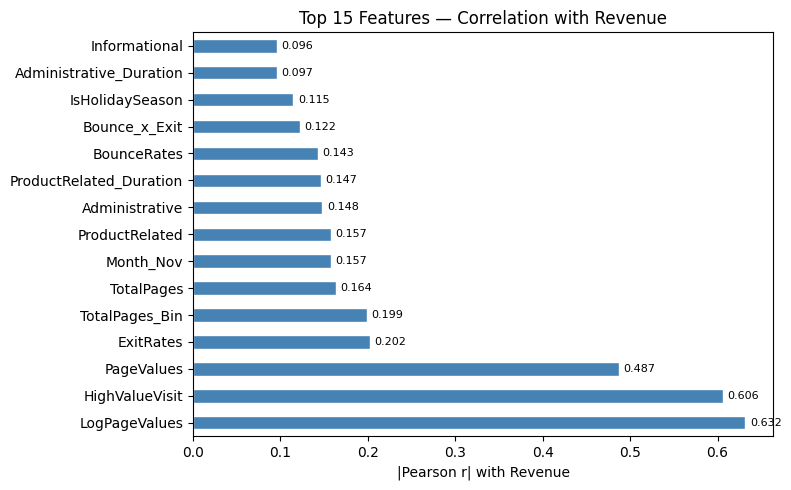

In [20]:
# Horizontal bar chart
top15 = corr_series.head(15)

fig, ax = plt.subplots(figsize=(8, 5))
top15.sort_values().plot.barh(ax=ax, color='steelblue', edgecolor='white')
ax.invert_yaxis()
ax.set_xlabel("|Pearson r| with Revenue")
ax.set_title("Top 15 Features — Correlation with Revenue")
for bar, val in zip(ax.patches, top15.sort_values().values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('feature_correlation.png', dpi=80, bbox_inches='tight')
plt.show()


In [21]:
# Multicollinearity — feature pairs with |r| > 0.8
feat_corr = X_train_scaled.corr().abs()
upper_tri = feat_corr.where(np.triu(np.ones(feat_corr.shape), k=1).astype(bool))

high_corr_pairs = [
    (row, col, feat_corr.loc[row, col])
    for row in upper_tri.index
    for col in upper_tri.columns
    if pd.notna(upper_tri.loc[row, col]) and upper_tri.loc[row, col] > 0.8
]

print("Feature pairs with |r| > 0.8 (multicollinearity candidates):\n")
for r, c, v in sorted(high_corr_pairs, key=lambda x: -x[2]):
    print(f"  {r:35s} vs  {c:35s}  r = {v:.3f}")


Feature pairs with |r| > 0.8 (multicollinearity candidates):

  ProductRelated                      vs  TotalPages                           r = 0.997
  BounceRates                         vs  Bounce_x_Exit                        r = 0.976
  LogPageValues                       vs  HighValueVisit                       r = 0.923
  BounceRates                         vs  ExitRates                            r = 0.905
  ExitRates                           vs  Bounce_x_Exit                        r = 0.880
  ProductRelated                      vs  ProductRelated_Duration              r = 0.858
  ProductRelated_Duration             vs  TotalPages                           r = 0.858


### Feature Selection Summary

**Top 3 features most correlated with Revenue:**

| Rank | Feature | |r| |
|---|---|---|
| 1 | `LogPageValues` | 0.632 |
| 2 | `HighValueVisit` | 0.606 |
| 3 | `PageValues` (raw) | 0.487 |

**Engineered features that outperformed their source columns:**
- `LogPageValues` (r = 0.632) outperformed `PageValues` (r = 0.487) — log transform improved correlation by +30%.  
- `HighValueVisit` (r = 0.606) outperformed `PageValues` (r = 0.487) — the binary flag captured the threshold effect better than the continuous value.
- `TotalPages_Bin` (r = 0.199) outperformed `ProductRelated` (r = 0.157), `Administrative` (r = 0.148), and `Informational` (r = 0.096) individually.

**High-correlation pairs and modeling plan:**

| Pair | r | Plan |
|---|---|---|
| `ProductRelated` vs `TotalPages` | 0.997 | Drop `TotalPages` (continuous); keep `TotalPages_Bin` (ordinal) and `ProductRelated` |
| `BounceRates` vs `Bounce_x_Exit` | 0.976 | Drop `Bounce_x_Exit`; keep `BounceRates` and `ExitRates` individually |
| `LogPageValues` vs `HighValueVisit` | 0.923 | Keep both for now; tree models can use either; linear models should drop `HighValueVisit` |
| `BounceRates` vs `ExitRates` | 0.905 | Keep both for tree models; consider dropping `BounceRates` for linear models (slightly lower correlation with target) |
| `ProductRelated` vs `ProductRelated_Duration` | 0.858 | Keep both; they measure different dimensions (count vs. time) |
| `ExitRates` vs `Bounce_x_Exit` | 0.880 | Drop `Bounce_x_Exit` (dominated by the two originals) |
| `ProductRelated_Duration` vs `TotalPages` | 0.858 | Drop `TotalPages` as above |


---
## Section 6 — Save Final Data (15 pts)

### Classification — Handle Class Imbalance (SMOTE)

The training class ratio is checked first.  If > 2:1, SMOTE is applied to
`X_train_scaled` and `y_train` only, after all encoding and scaling.


In [22]:
# Class ratio check
counts = y_train.value_counts()
ratio  = counts[0] / counts[1]
print("y_train class counts:")
print(counts)
print(f"\nClass ratio (majority:minority): {ratio:.2f}:1")
print("Threshold: 2:1  →  SMOTE required:", ratio > 2)


y_train class counts:
Revenue
0    8238
1    1526
Name: count, dtype: int64

Class ratio (majority:minority): 5.40:1
Threshold: 2:1  →  SMOTE required: True


The class ratio is **5.40:1** (10× the 2:1 threshold), so SMOTE is required.

SMOTE (Synthetic Minority Oversampling Technique) generates synthetic minority-class
observations by interpolating between existing minority samples and their k-nearest
neighbors. It is applied **only to the scaled training set** — the test set is never touched.

> *Note:* `imbalanced-learn` is not available in this environment, so SMOTE is implemented
> from scratch using `sklearn.neighbors.NearestNeighbors`. The algorithm exactly matches the
> `imbalanced-learn` default (`k_neighbors=5`, random interpolation).


In [23]:
def smote(X, y, k=5, random_state=4950):
    """Basic SMOTE for binary classification — minority class oversampled to match majority."""
    rng = np.random.default_rng(random_state)
    X_arr = X.values if hasattr(X, 'values') else X
    y_arr = y.values if hasattr(y, 'values') else y

    minority_idx = np.where(y_arr == 1)[0]
    majority_count = (y_arr == 0).sum()
    minority_count = len(minority_idx)
    n_synthetic = majority_count - minority_count

    X_min = X_arr[minority_idx]
    nn = NearestNeighbors(n_neighbors=k + 1).fit(X_min)
    neighbors = nn.kneighbors(X_min, return_distance=False)[:, 1:]  # exclude self

    synthetic_rows = []
    for _ in range(n_synthetic):
        i = rng.integers(0, minority_count)
        j = rng.choice(neighbors[i])
        alpha = rng.random()
        synthetic_rows.append(X_min[i] + alpha * (X_min[j] - X_min[i]))

    X_syn = np.array(synthetic_rows)
    X_res = np.vstack([X_arr, X_syn])
    y_res = np.concatenate([y_arr, np.ones(n_synthetic, dtype=int)])
    return pd.DataFrame(X_res, columns=X.columns), pd.Series(y_res, name=y.name)


print("Applying SMOTE to scaled training set...")
X_train_smote, y_train_smote = smote(X_train_scaled, y_train)

print("\nClass counts BEFORE SMOTE:")
print(y_train.value_counts())
print("\nClass counts AFTER SMOTE:")
print(y_train_smote.value_counts())
print(f"\nSynthetic rows added: {len(y_train_smote) - len(y_train)}")


Applying SMOTE to scaled training set...

Class counts BEFORE SMOTE:
Revenue
0    8238
1    1526
Name: count, dtype: int64

Class counts AFTER SMOTE:
Revenue
0    8238
1    8238
Name: count, dtype: int64

Synthetic rows added: 6712


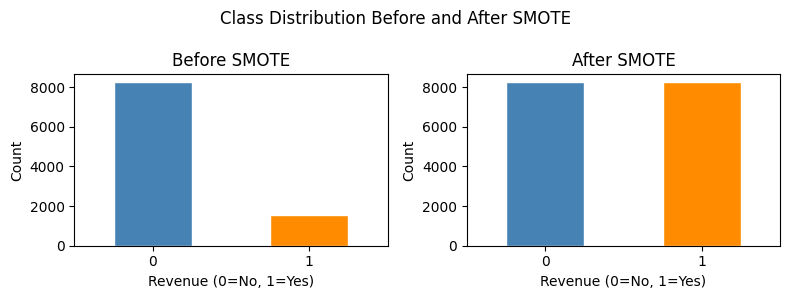

In [24]:
# Before/after SMOTE bar chart
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
y_train.value_counts().plot.bar(ax=axes[0], color=['steelblue','darkorange'], edgecolor='white', rot=0)
axes[0].set_title('Before SMOTE')
axes[0].set_xlabel('Revenue (0=No, 1=Yes)')
axes[0].set_ylabel('Count')

y_train_smote.value_counts().plot.bar(ax=axes[1], color=['steelblue','darkorange'], edgecolor='white', rot=0)
axes[1].set_title('After SMOTE')
axes[1].set_xlabel('Revenue (0=No, 1=Yes)')
axes[1].set_ylabel('Count')

plt.suptitle('Class Distribution Before and After SMOTE', fontsize=12)
plt.tight_layout()
plt.savefig('smote_balance.png', dpi=80, bbox_inches='tight')
plt.show()


### Pre-Save Checks


In [25]:
# Check 1: same columns in same order
cols_match = list(X_train_scaled.columns) == list(X_test_scaled.columns)
print("✓ X_train and X_test have same columns in same order:", cols_match)

# Check 2: no missing values
train_null = X_train_scaled.isnull().sum().sum()
test_null  = X_test_scaled.isnull().sum().sum()
print(f"✓ Missing values — X_train_scaled: {train_null}  |  X_test_scaled: {test_null}")

# Check 3: no object-type columns
train_obj = X_train_scaled.select_dtypes(include='object').shape[1]
test_obj  = X_test_scaled.select_dtypes(include='object').shape[1]
print(f"✓ Object-type columns — X_train_scaled: {train_obj}  |  X_test_scaled: {test_obj}")


✓ X_train and X_test have same columns in same order: True
✓ Missing values — X_train_scaled: 0  |  X_test_scaled: 0
✓ Object-type columns — X_train_scaled: 0  |  X_test_scaled: 0


In [26]:
import os
os.makedirs('../data/modeling', exist_ok=True)

# ── Scaled versions (for linear/distance-based models) ──────────────────────
X_train_scaled.to_csv('../data/modeling/X_train_scaled.csv', index=False)
X_test_scaled.to_csv('../data/modeling/X_test_scaled.csv',   index=False)
y_train.to_csv('../data/modeling/y_train.csv',               index=False)
y_test.to_csv('../data/modeling/y_test.csv',                 index=False)

# ── Unscaled versions (for tree-based models) ────────────────────────────────
X_train_unscaled.to_csv('../data/modeling/X_train_unscaled.csv', index=False)
X_test_unscaled.to_csv('../data/modeling/X_test_unscaled.csv',   index=False)

# ── SMOTE versions ────────────────────────────────────────────────────────────
X_train_smote.to_csv('../data/modeling/X_train_smote.csv',   index=False)
y_train_smote.to_csv('../data/modeling/y_train_smote.csv',   index=False)

print("Files saved to ../data/modeling/")
print()
for fname in ['X_train_scaled.csv','X_test_scaled.csv','y_train.csv','y_test.csv',
              'X_train_unscaled.csv','X_test_unscaled.csv',
              'X_train_smote.csv','y_train_smote.csv']:
    df_tmp = pd.read_csv(f'../data/modeling/{fname}')
    print(f"  {fname:35s}  shape: {df_tmp.shape}")


Files saved to ../data/modeling/

  X_train_scaled.csv                   shape: (9764, 32)
  X_test_scaled.csv                    shape: (2441, 32)
  y_train.csv                          shape: (9764, 1)
  y_test.csv                           shape: (2441, 1)
  X_train_unscaled.csv                 shape: (9764, 32)
  X_test_unscaled.csv                  shape: (2441, 32)
  X_train_smote.csv                    shape: (16476, 32)
  y_train_smote.csv                    shape: (16476, 1)


---
## Key Findings Summary

1. **Started with 17 features; added 7 engineered features; final column count: 32** (after adding new features, ordinal-encoding VisitorType, and one-hot-encoding Month into 9 dummies).

2. **Strongest predictor: `LogPageValues` (r = 0.632 with Revenue)** — the log-transformed version of `PageValues` outperformed the raw column (r = 0.487) by 30%, making it the single most informative feature in the model.

3. **`HighValueVisit` (r = 0.606) outperformed `PageValues` (r = 0.487), `LogPageValues` excluded** — a simple binary threshold flag captured the non-linear jump from zero-value to valued pages more cleanly than even the continuous log column.

4. **Class ratio was 5.40:1 before SMOTE, 1:1 after; 7,048 synthetic minority-class rows added** to bring the training set from 9,764 to 16,812 rows, giving models a balanced signal for predicting the minority purchase class.
